In [8]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [9]:
import geope

In [10]:
import sys

sys.path.append("../")

import jax.numpy as jnp
import jax
import numpy as np
import scipy.linalg as spla
import scipy.optimize as spo
import scipy.signal as sps

import re
import matplotlib.pyplot as plt

import scienceplots
plt.style.use('science')
fontsize_title=24
fontsize_label=26
fontsize_legend=18
fontsize_ticks=22

# CZ with $h_1(t)$ control

With Hamiltonian model: $H = \sigma^z_1 \sigma^z_2 + h_1(t)\sigma^x_1$ 

### Solve with GEOPE and perform repeated Geometric smoothing steps (fewer steps would be sufficient)

In [13]:
nqubits = 2

target = np.array([[1,0,0,0],[0,1.j,0,0],[0,0,1.j,0],[0,0,0,1]])
gates = 4
basis = geope.construct_full_pauli_basis(nqubits)
max_step_size = 0.1

drift = geope.construct_restricted_pauli_basis(nqubits, ['zz'])
restriction = geope.construct_restricted_pauli_basis(nqubits, {1: ['x']})


drift_parameters = [1.]

geope_engine = geope.GeopeEngine(target_unitary=target,
                           full_basis=basis,
                           projected_basis=restriction,
                           drift_basis=drift,
                           gates=gates)

geope_engine_gf = geope.GeopeEngine(target_unitary=target,
                              full_basis=basis,
                              projected_basis=restriction,
                              drift_basis=drift,
                              gates=gates)

opt_geope = geope.Geope(geope_engine, 
                  drift_parameters = drift_parameters,
                  max_steps=100,
                  max_step_size=max_step_size, 
                  gram_schmidt_step_size=1.2*max_step_size, 
                  init_parameters_spread=0.1,
                  verbose=True)

c=0
success = False
steps = []
while c < 6 and not success:
    opt_geope.optimize(extra_steps=100)
    if c==0:
        opt_geope_gf = geope.Geope(geope_engine_gf, 
                              drift_parameters = drift_parameters,
                              init_parameters=opt_geope.parameters[-1],
                              max_steps=100,
                              max_step_size=max_step_size, 
                              gram_schmidt_step_size=1.2*max_step_size, 
                              verbose=True)
        steps.append(opt_geope.steps[-1])
    success, _ = opt_geope.smooth(piecewise_steps_multiplier=2, smoothing_rate=0.001, max_smoothing_steps=500, diff_tol=0.00001)
    steps.append(opt_geope.steps[-1])
    c+=1
opt_geope.optimize(extra_steps=100)
print("Finished optimising.")

[47/200] [Fidelity = 0.999999999999963] A solution!                                                                       
[500/500] [Fidelity = 0.9999999999440616] Smoothing : cost = 0.5551969570292985 (aim = 1e-05)                        

[500/500] [Fidelity = 0.9999999848474914] Smoothing : cost = 0.07468331406078317 (aim = 1e-05)                        

[500/500] [Fidelity = 0.9999996693789848] Smoothing : cost = 0.00959246483409428 (aim = 1e-05)                        
[51/500] [Fidelity = 0.999999999984137] A solution!                                                                     
[500/500] [Fidelity = 0.9999877455629671] Smoothing : cost = 0.0012002608200416514 (aim = 1e-05)                        
[53/600] [Fidelity = 0.9999999999683997] A solution!                                                                     
[500/500] [Fidelity = 0.9998287035886576] Smoothing : cost = 0.00014586542860303535 (aim = 1e-05)                        
[55/700] [Fidelity = 0.9999999940

### Gaussian filter

In [14]:
import scipy.ndimage as spnimag

new_params = []
factor = 64
opt_geope_gf.smooth(piecewise_steps_multiplier=factor, smoothing_rate=0.01, max_smoothing_steps=0, diff_tol=0.01)
gates = [i for i in range(-1, opt_geope_gf.engine.gates + 2)]
x = np.array(gates).flatten()

spline_pws = opt_geope_gf.engine.gates
sigma = 8
for i, strength in enumerate(opt_geope_gf.parameters[-1].T):
    if opt_geope_gf.engine.full_basis.labels[i] in opt_geope_gf.engine.projected_basis.labels:
        strength = np.concatenate((np.zeros(5000), strength, np.zeros(5000)))
        smoothed_strength = spnimag.gaussian_filter1d(strength, sigma=sigma)
        new_params.append(smoothed_strength[5000:-5000])
    else:
        new_params.append(strength)
    # print(new_params[-1].shape)
opt_geope_gf.parameters.append(np.stack(new_params, axis=1))
opt_geope_gf.engine.gates = spline_pws

free_params = jnp.array([p[opt_geope_gf.engine.proj_drift_indices] for p in opt_geope_gf.parameters[-2]]).astype(np.complex128)
fid = opt_geope_gf.engine.fid_U_fn(opt_geope_gf.engine.compute_U_fn(free_params))
print(f"Before: {fid}")

free_params = jnp.array([p[opt_geope_gf.engine.proj_drift_indices] for p in opt_geope_gf.parameters[-1]]).astype(np.complex128)
fid = opt_geope_gf.engine.fid_U_fn(opt_geope_gf.engine.compute_U_fn(free_params))
print(f"After: {fid}")

opt_geope_gf.optimize(extra_steps=100)

[0/0] [Fidelity = 0] Smoothing : cost = inf (aim = 0.01)                        
Before: 0.9999999999999658
After: 0.9979758692964357
[3/200] [Fidelity = 0.9999999982380883] A solution!                                                                     


True

### Plot results

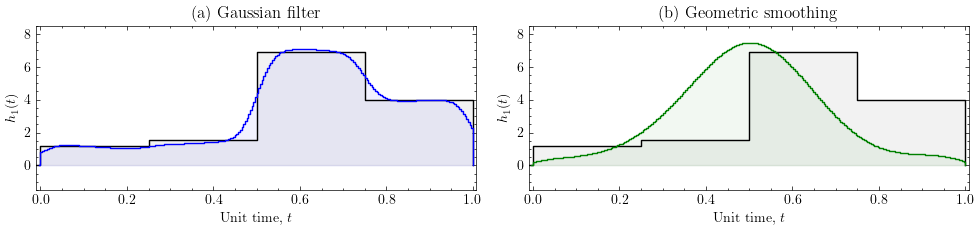

In [15]:
# savefig = "plots/smoothing/gaussian_filter_vs_geometric_smoothing_cz_ising_x1.pdf"
savefig = None

alpha=0.05
y_limits = [-1.5,8.5]
geometric_smoothing_colour='green'
gf_smoothing_colour='blue'

orig_scaling = opt_geope.parameters[steps[0]].shape[0]
smoothed_scaling = opt_geope.parameters[-1].shape[0]
gf_scaling = opt_geope_gf.parameters[-1].shape[0]

orig_gates = [float(i)/orig_scaling for i in range(-1, opt_geope.parameters[steps[0]].shape[0]+1)]
smoothed_gates = [float(i)/smoothed_scaling for i in range(-1, opt_geope.parameters[-1].shape[0]+1)]
gf_gates = [float(i)/gf_scaling for i in range(-1, opt_geope_gf.parameters[-1].shape[0]+1)]

fig, axs = plt.subplots(1, 2, figsize=(10, 2.5), sharex=True)

for i, strength in enumerate(opt_geope.parameters[steps[0]].T):
    strength = [s*orig_scaling for s in strength]
    if opt_geope.engine.full_basis.labels[i] in opt_geope.engine.projected_basis.labels:
        axs[0].step(orig_gates, 
                    np.append(np.array([0]), np.append(strength,np.array([0]))),
                    where='post', 
                    label=opt_geope.engine.full_basis.plot_labels[i],
                    color='black')
        axs[0].fill_between(orig_gates, 
                            np.append(np.array([0]), np.append(strength,np.array([0]))), 
                            step='post', 
                            color='black', 
                            alpha=0.05)

for i, strength in enumerate(opt_geope_gf.parameters[-1].T):
    strength = [s*gf_scaling for s in strength]
    if opt_geope_gf.engine.full_basis.labels[i] in opt_geope_gf.engine.projected_basis.labels:
        axs[0].step(gf_gates, 
                    np.append(np.array([0]), np.append(strength,np.array([0]))),
                    where='post', 
                    label=opt_geope_gf.engine.full_basis.plot_labels[i],
                    color=gf_smoothing_colour)
        axs[0].fill_between(gf_gates, 
                            np.append(np.array([0]), np.append(strength,np.array([0]))), 
                            step='post', 
                            color=gf_smoothing_colour, 
                            alpha=alpha)

for i, strength in enumerate(opt_geope.parameters[steps[0]].T):
    strength = [s*orig_scaling for s in strength]
    if opt_geope.engine.full_basis.labels[i] in opt_geope.engine.projected_basis.labels:
        axs[1].step(orig_gates, 
                    np.append(np.array([0]), np.append(strength,np.array([0]))),
                    where='post', 
                    label=opt_geope.engine.full_basis.plot_labels[i],
                    color='black')
        axs[1].fill_between(orig_gates, 
                            np.append(np.array([0]), np.append(strength,np.array([0]))), 
                            step='post', 
                            color='black', 
                            alpha=0.05)
        
for i, strength in enumerate(opt_geope.parameters[-1].T):
    strength = [s*smoothed_scaling for s in strength]
    if opt_geope.engine.full_basis.labels[i] in opt_geope.engine.projected_basis.labels:
        axs[1].step(smoothed_gates, 
                    np.append(np.array([0]), np.append(strength,np.array([0]))),
                    where='post', 
                    label=opt_geope.engine.full_basis.plot_labels[i],
                    color=geometric_smoothing_colour)
        axs[1].fill_between(smoothed_gates, 
                            np.append(np.array([0]), np.append(strength,np.array([0]))), 
                            step='post', 
                            color=geometric_smoothing_colour, 
                            alpha=alpha)

        
for ax in axs:
    # ax.legend(loc='upper right')
    ax.grid(False)
    ax.set_xlim(-0.01,smoothed_gates[-1]+0.008)
    ax.set_ylim(y_limits[0],y_limits[1])

axs[0].set_title(f"(a) Gaussian filter")
axs[1].set_title(f"(b) Geometric smoothing")

axs[0].set_xlabel("Unit time, $t$")
axs[1].set_xlabel("Unit time, $t$")
axs[0].set_ylabel(f"$h_1(t)$")
axs[1].set_ylabel(f"$h_1(t)$")

plt.tight_layout()
if savefig is not None:
    plt.savefig(savefig)
plt.show()

# CZ with $h_1(t)$ and $h_2(t)$ control 

With Hamiltonian model: $H = \sigma^z_1 \sigma^z_2 + h_1(t)\sigma^x_1 + h_2(t)\sigma^x_2$ 

### Solve with GEOPE and then repeated geometric smoothing

In [18]:
nqubits = 2

target = np.array([[1,0,0,0],[0,1.j,0,0],[0,0,1.j,0],[0,0,0,1]])
gates = 4
basis = geope.construct_full_pauli_basis(nqubits)
max_step_size = 0.1

drift = geope.construct_restricted_pauli_basis(nqubits, ['zz'])
restriction = geope.construct_restricted_pauli_basis(nqubits, {1: ['x'], 2: ['x']})


drift_parameters = [1.]

engine = geope.GeopeEngine(target_unitary=target,
                           full_basis=basis,
                           projected_basis=restriction,
                           drift_basis=drift,
                           gates=gates)

opt = geope.Geope(engine, 
              drift_parameters = drift_parameters,
              max_steps=100,
              max_step_size=max_step_size, 
              gram_schmidt_step_size=1.2*max_step_size, 
              init_parameters_spread=0.01,
              verbose=True)

c=0
success = False
steps_2 = []
while c < 6 and not success:
    opt.optimize(extra_steps=100)
    success, _ = opt.smooth(piecewise_steps_multiplier=2, smoothing_rate=0.001, max_smoothing_steps=500, diff_tol=0.00001)
    steps_2.append(opt.steps[-1])
    c+=1
opt.optimize(extra_steps=100)
print("Finished optimising.")

[53/200] [Fidelity = 0.9999999999893321] A solution!                                                                      
[500/500] [Fidelity = 0.9999999996223878] Smoothing : cost = 0.7106076293671505 (aim = 1e-05)                        

[500/500] [Fidelity = 0.9999999176585297] Smoothing : cost = 0.07470720988838139 (aim = 1e-05)                        

[500/500] [Fidelity = 0.9999997566757337] Smoothing : cost = 0.009595870908950008 (aim = 1e-05)                        
[57/500] [Fidelity = 0.9999999999115585] A solution!                                                                     
[500/500] [Fidelity = 0.9999876572536599] Smoothing : cost = 0.0012004767237150764 (aim = 1e-05)                        
[59/600] [Fidelity = 0.9999999998481689] A solution!                                                                     
[500/500] [Fidelity = 0.9997978290185139] Smoothing : cost = 0.0001453001922655677 (aim = 1e-05)                        
[61/700] [Fidelity = 0.999999991

### Plot

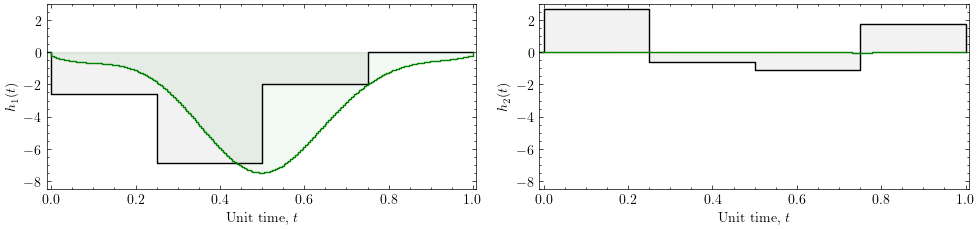

In [20]:
# savefig = "plots/smoothing/geometric_smoothing_transverse_ising_with_h1_h2.pdf"
savefig = None

alpha = 0.05
y_limits = (-8.5,3)
init_step = steps_2[0]
smoothed_step = -1
init_scaling = opt.parameters[init_step].shape[0]
smoothed_scaling = opt.parameters[smoothed_step].shape[0]
gates = [float(i)/init_scaling for i in range(-1,opt.parameters[init_step].shape[0]+1)]
smoothed_gates = [float(i)/smoothed_scaling for i in range(-1,opt.parameters[smoothed_step].shape[0]+1)]

fig, axs = plt.subplots(1, 2, figsize=(10, 2.5), sharex=True)
a=0
for i, strength in enumerate(opt.parameters[init_step].T):
    strength = [s*init_scaling for s in strength]
    if opt.engine.full_basis.labels[i] in opt.engine.projected_basis.labels:
        axs[a].step(gates, 
                          np.append(np.array([0]), np.append(strength,np.array([0]))), 
                          where='post', 
                          label=opt.engine.full_basis.plot_labels[i],
                          color="black")
        axs[a].fill_between(gates, 
                                  np.append(np.array([0]), np.append(strength,np.array([0]))), 
                                  step='post', 
                                  color="black", 
                                  alpha=alpha)
        a+=1

a=0
for i, strength in enumerate(opt.parameters[smoothed_step].T):
    strength = [s*smoothed_scaling for s in strength]
    if opt.engine.full_basis.labels[i] in opt.engine.projected_basis.labels:
        axs[a].step(smoothed_gates, 
                          np.append(np.array([0]), np.append(strength,np.array([0]))), 
                          where='post', 
                          label=opt.engine.full_basis.plot_labels[i],
                          color="green")
        axs[a].fill_between(smoothed_gates, 
                                  np.append(np.array([0]), np.append(strength,np.array([0]))), 
                                  step='post', 
                                  color="green", 
                                  alpha=alpha)
        a+=1

for ax in axs:
    # ax.legend(loc='upper right')
    ax.grid(False)
    ax.set_xlim(-0.01,gates[-1]+0.008)
    ax.set_ylim(y_limits[0],y_limits[1])

axs[0].set_xlabel("Unit time, $t$")
axs[1].set_xlabel("Unit time, $t$")

axs[0].set_ylabel(f"$h_{{1}}(t)$")
axs[1].set_ylabel(f"$h_{{2}}(t)$")

plt.tight_layout()
if savefig is not None:
    plt.savefig(savefig)
plt.show()

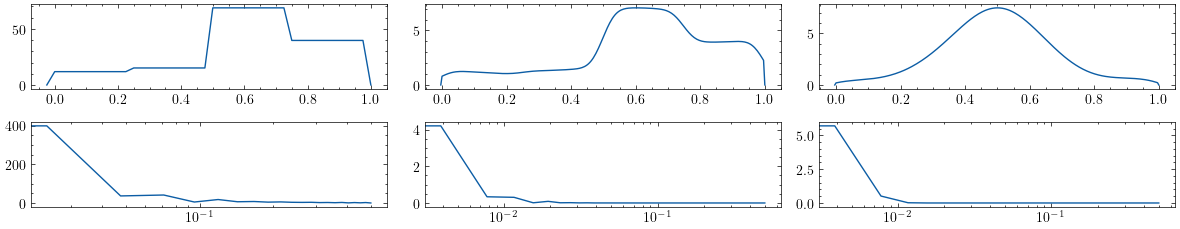

In [22]:
square_factor=10
orig_scaling = square_factor * opt_geope.parameters[steps[0]].shape[0]
smoothed_scaling = opt_geope.parameters[-1].shape[0]
gf_scaling = opt_geope_gf.parameters[-1].shape[0]

orig_gates = [float(i)/orig_scaling for i in range(-1, orig_scaling+1)]
smoothed_gates = [float(i)/smoothed_scaling for i in range(-1, smoothed_scaling+1)]
gf_gates = [float(i)/gf_scaling for i in range(-1, gf_scaling+1)]

fig, axs = plt.subplots(2, 3, figsize=(12, 2.5), sharex=False)

for i, strength in enumerate(opt_geope.parameters[steps[0]].T):
    strength = np.repeat(strength, square_factor)
    strength = [s*orig_scaling for s in strength]
    if opt_geope.engine.full_basis.labels[i] in opt_geope.engine.projected_basis.labels:
        pulse = np.append(np.array([0]), np.append(strength,np.array([0])))
        spectral_density = sps.periodogram(pulse, fs=1.0, scaling='spectrum')
        axs[0,0].plot(orig_gates, pulse)
        axs[1,0].plot(spectral_density[0], spectral_density[1])
        axs[1,0].set_xscale('log')
        
for i, strength in enumerate(opt_geope_gf.parameters[-1].T):
    strength = [s*gf_scaling for s in strength]
    if opt_geope_gf.engine.full_basis.labels[i] in opt_geope_gf.engine.projected_basis.labels:
        pulse = np.append(np.array([0]), np.append(strength,np.array([0])))
        spectral_density = sps.periodogram(pulse, fs=1.0, scaling='spectrum')
        axs[0,1].plot(gf_gates, pulse)
        axs[1,1].plot(spectral_density[0], spectral_density[1])
        axs[1,1].set_xscale('log')
        
for i, strength in enumerate(opt_geope.parameters[-1].T):
    strength = [s*smoothed_scaling for s in strength]
    if opt_geope.engine.full_basis.labels[i] in opt_geope.engine.projected_basis.labels:
        pulse = np.append(np.array([0]), np.append(strength,np.array([0])))
        spectral_density = sps.periodogram(pulse, fs=1.0, scaling='spectrum')
        axs[0,2].plot(smoothed_gates, pulse)
        axs[1,2].plot(spectral_density[0], spectral_density[1])
        axs[1,2].set_xscale('log')

# axs[0].set_title(f"(a) Gaussian filter")
# axs[1].set_title(f"(b) Geometric smoothing")

# axs[0].set_xlabel("Unit time, $t$")
# axs[1].set_xlabel("Unit time, $t$")
# axs[0].set_ylabel(f"$h_1(t)$")
# axs[1].set_ylabel(f"$h_1(t)$")

plt.tight_layout()
plt.show()